# Step 4: Model Evaluation & Visualization

In questo notebook finale eseguiamo una valutazione completa del modello migliore selezionato (LSTM Best Run).
L'obiettivo è validare le prestazioni su tre livelli:
1.  **Model Selection:** Confronto con le altre architetture testate.
2.  **Latent Space Diagnostics:** Analisi statistica delle predizioni nello spazio compresso (R², Bias).
3.  **Physical Space Verification:** Decodifica delle predizioni in coordinate atomiche reali (End-to-End).
4.  **Generative Stability:** Test di generazione autoregressiva (Ghost Trajectories) per verificare la stabilità a lungo termine.

**Requisiti:**
* Dati processati dallo Step 2 (`processed_step2_triple_head`)
* Modello LSTM addestrato (`saved_models_dynamics_lstm`)
* Autoencoder completo per la decodifica (`saved_models_triple`)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'lines.linewidth': 2
})



c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Evaluation 0: Model Selection (The Tournament)

Prima di analizzare il modello nel dettaglio, confrontiamo le prestazioni delle diverse configurazioni testate (LSTM vs Transformer vs Baseline).
I valori riportati provengono dai log di training dello Step 3.

**Obiettivo:** Giustificare quantitativamente la scelta della LSTM (Best Run) come modello finale.

Loading raw data from: processed_step2_triple_head

STARTING MODEL EVALUATION
Baseline (Inertia) MSE: 0.14116
Evaluating: LSTM Best (SeqLen=10)...

   Success! MSE: 0.03528
Evaluating: LSTM HighReg (SeqLen=10)...
   Success! MSE: 0.08773
Evaluating: LSTM Light (SeqLen=10)...
   Success! MSE: 0.06581
Evaluating: LSTM LongWin (SeqLen=20)...
   Success! MSE: 0.04534
Evaluating: Trans Complex (SeqLen=10)...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


   Success! MSE: 0.03285
Evaluating: Trans Standard (SeqLen=10)...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


   Success! MSE: 0.06533
Evaluating: Trans LongWin (SeqLen=20)...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


   Success! MSE: 0.04637


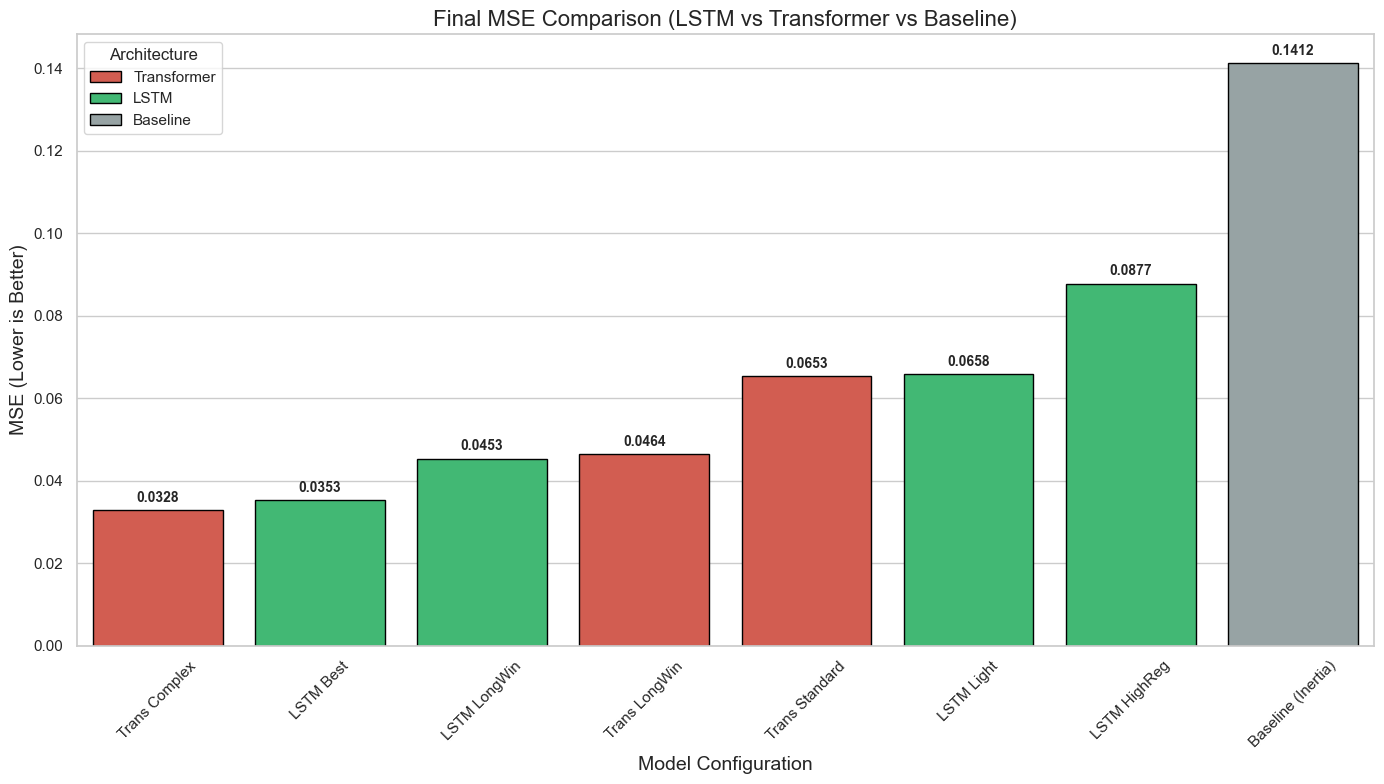

In [2]:
# =============================================================================
# MODEL EVALUATION AND COMPARISON
# =============================================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CUSTOM CLASSES DEFINITION (Required for loading Transformer models)
class PositionalEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        return x + self.pos_emb(positions)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "seq_len": self.pos_emb.input_dim,
            "d_model": self.d_model,
        })
        return config

# 2. RAW DATA LOADING (To regenerate sequences on the fly)
DATA_PATH = "processed_step2_triple_head"
print(f"Loading raw data from: {DATA_PATH}")
test_df = pd.read_csv(os.path.join(DATA_PATH, "test_dataset.csv"))
test_raw = test_df.values.astype(np.float32)

# Helper function to create sequences with variable lengths
def create_eval_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i : i + seq_length])
        ys.append(data[i + seq_length])
    return np.asarray(xs), np.asarray(ys)

# 3. MODEL LIST
models_list = [
    # --- LSTM ---
    {'name': 'LSTM Best',       'path': 'saved_models_dynamics_lstm/LSTM_Best_Run/best_model.keras',       'type': 'LSTM',        'seq_len': 10},
    {'name': 'LSTM HighReg',    'path': 'saved_models_dynamics_lstm/LSTM_HighReg_Run/best_model.keras',    'type': 'LSTM',        'seq_len': 10},
    {'name': 'LSTM Light',      'path': 'saved_models_dynamics_lstm/LSTM_Light_Run/best_model.keras',      'type': 'LSTM',        'seq_len': 10},
    {'name': 'LSTM LongWin',    'path': 'saved_models_dynamics_lstm/LSTM_LongWindow_Run/best_model.keras', 'type': 'LSTM',        'seq_len': 20},
    
    # --- TRANSFORMER ---
    {'name': 'Trans Complex',   'path': 'saved_models_dynamics_transformer/Trans_Complex/best_model.keras',    'type': 'Transformer', 'seq_len': 10},
    {'name': 'Trans Standard',  'path': 'saved_models_dynamics_transformer/Trans_Standard/best_model.keras',   'type': 'Transformer', 'seq_len': 10},
    {'name': 'Trans LongWin',   'path': 'saved_models_dynamics_transformer/Trans_LongWindow/best_model.keras', 'type': 'Transformer', 'seq_len': 20},
]

results_data = []

print("\nSTARTING MODEL EVALUATION")
print("=" * 60)

# 4. BASELINE CALCULATION (Inertia) on seq_len=10 (Standard)
X_test_10, y_true_10 = create_eval_sequences(test_raw, seq_length=10)
y_pred_baseline = X_test_10[:, -1, :] 
mse_baseline = mean_squared_error(y_true_10, y_pred_baseline)
results_data.append({'Model': 'Baseline (Inertia)', 'Type': 'Baseline', 'MSE': mse_baseline})
print(f"Baseline (Inertia) MSE: {mse_baseline:.5f}")

# 5. EVALUATION LOOP
for m in models_list:
    if os.path.exists(m['path']):
        try:
            print(f"Evaluating: {m['name']} (SeqLen={m['seq_len']})...")
            
            # A. Data Preparation specific to the model
            curr_X_test, curr_y_true = create_eval_sequences(test_raw, seq_length=m['seq_len'])
            
            # B. Model Loading (With Custom Objects for Transformers)
            model = load_model(m['path'], safe_mode=False, custom_objects={"PositionalEmbedding": PositionalEmbedding})
            
            # C. Prediction
            y_pred = model.predict(curr_X_test, verbose=0)
            
            # D. MSE Calculation
            mse = mean_squared_error(curr_y_true, y_pred)
            results_data.append({'Model': m['name'], 'Type': m['type'], 'MSE': mse})
            print(f"   Success! MSE: {mse:.5f}")
            
        except Exception as e:
            print(f"   Critical error on {m['name']}: {e}")
    else:
        print(f"   File not found: {m['path']}")

# =============================================================================
# 6. FINAL PLOT
# =============================================================================
if len(results_data) > 0:
    df_results = pd.DataFrame(results_data).sort_values(by='MSE', ascending=True)
    df_results.to_csv("Table_1_Model_Selection_Complete.csv", index=False)
    
    plt.figure(figsize=(14, 8))
    barplot = sns.barplot(
        data=df_results, 
        x='Model', 
        y='MSE', 
        hue='Type', 
        palette={'LSTM': '#2ecc71', 'Transformer': '#e74c3c', 'Baseline': '#95a5a6'}, 
        edgecolor='black'
    )

    for p in barplot.patches:
        if p.get_height() > 0:
            barplot.annotate(format(p.get_height(), '.4f'), 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha = 'center', va = 'center', 
                             xytext = (0, 9), textcoords = 'offset points', 
                             fontsize=10, weight='bold')

    plt.title('Final MSE Comparison (LSTM vs Transformer vs Baseline)', fontsize=16)
    plt.xlabel('Model Configuration')
    plt.ylabel('MSE (Lower is Better)')
    plt.xticks(rotation=45)
    plt.legend(title='Architecture')
    plt.tight_layout()
    plt.savefig("Model_Evaluation_Comparison.jpg", dpi=300)
    plt.show()
else:
    print("No results to show.")

## 2. Evaluation 1: Latent Space Diagnostics

Qui analizziamo come il modello si comporta nello "Spazio Latente" (il riassunto compresso della proteina).
Verifichiamo tre aspetti chiave per scoprire eventuali bias:
1.  **Learning per Dimensione:** Il modello impara tutte le feature o ne ignora alcune? (Bar Plot R²)
2.  **Dinamica Temporale:** Il modello segue le oscillazioni o fa solo la media? (Time Series Plot)
3.  **Correlazione Globale:** Esistono bias sistematici di sovrastima/sottostima? (Scatter Plot)

 Loading Selected Model: Transformer Complex
 Path: saved_models_dynamics_transformer/Trans_Complex/best_model.keras


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


 Model loaded successfully.
 Preparing Test Set (Window=10)...
 Generating predictions...
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


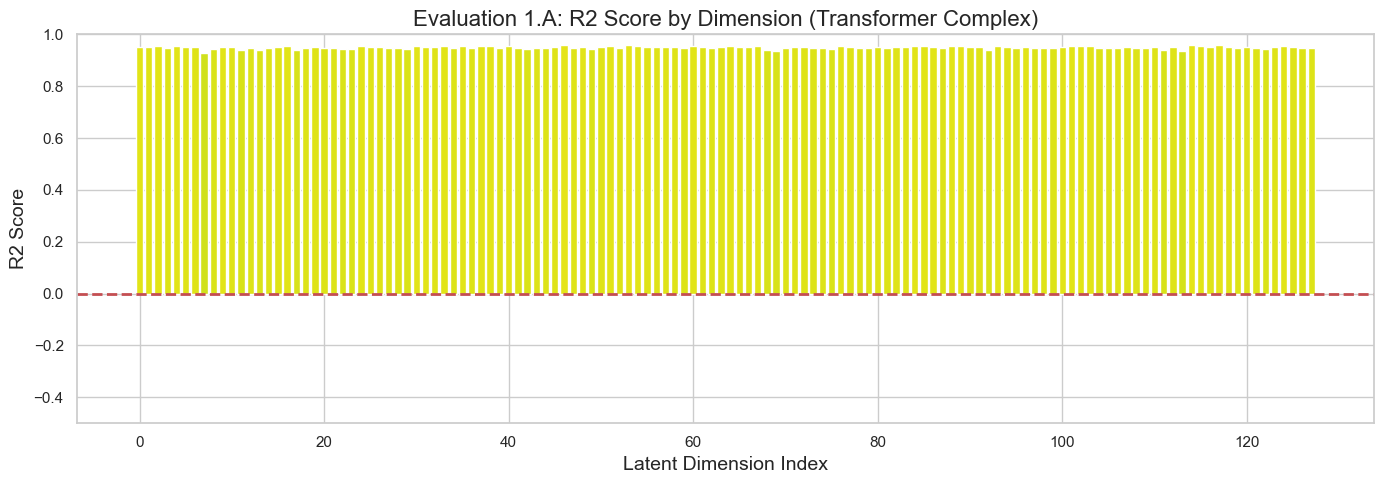

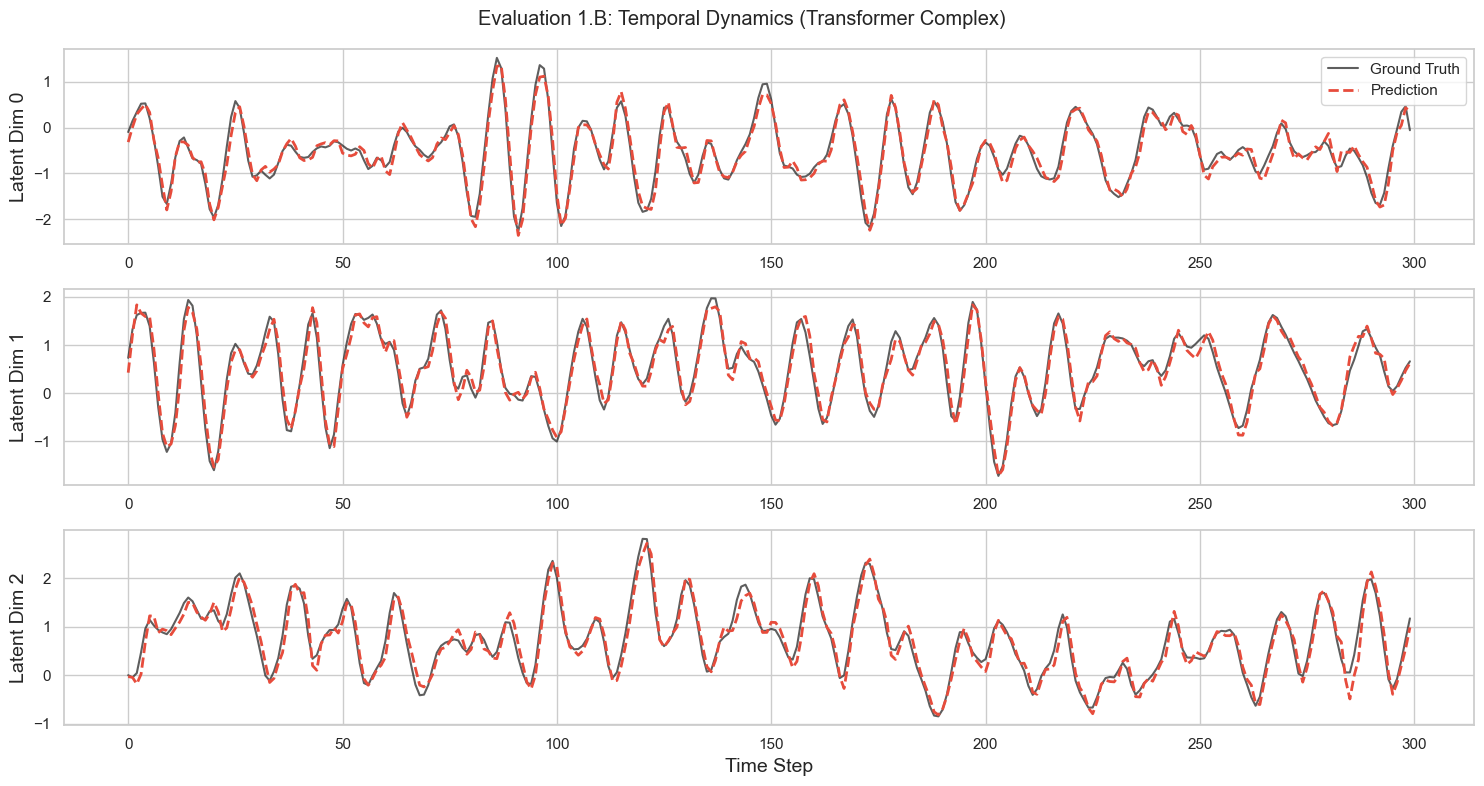

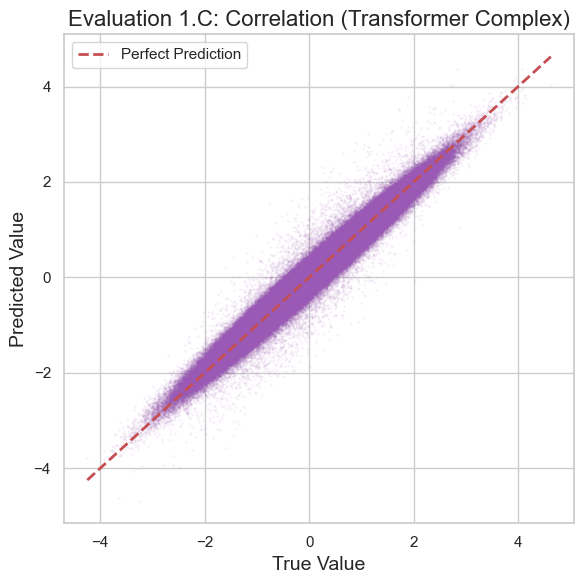

In [3]:
# =============================================================================
# EVALUATION 1: LATENT SPACE DIAGNOSTICS (Selected Model)
# =============================================================================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. CONFIGURATION
# Path to the model selected based on the previous comparative study
SELECTED_MODEL_PATH = "saved_models_dynamics_transformer/Trans_Complex/best_model.keras" 
MODEL_NAME = "Transformer Complex"
SEQ_LEN = 10 # Sequence length associated with the selected architecture

print(f" Loading Selected Model: {MODEL_NAME}")
print(f" Path: {SELECTED_MODEL_PATH}")

# 2. MODEL LOADING
# The 'PositionalEmbedding' class must be passed to custom_objects for deserialization
# Note: Ensure the PositionalEmbedding class is defined in the current namespace
try:
    model = load_model(SELECTED_MODEL_PATH, safe_mode=False, custom_objects={"PositionalEmbedding": PositionalEmbedding})
    print(" Model loaded successfully.")
except NameError:
    print(" ERROR: The class 'PositionalEmbedding' is not defined.")
    print(" Please ensure the class definition cell has been executed.")
    raise

# 3. DATA PREPARATION
# Regenerating sequences to ensure strict consistency with the model's SEQ_LEN
def create_eval_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i : i + seq_length])
        ys.append(data[i + seq_length])
    return np.asarray(xs), np.asarray(ys)

print(f" Preparing Test Set (Window={SEQ_LEN})...")
# Assuming 'test_raw' is available from the previous step. 
# If not, ensure the dataset is loaded before running this block.
X_test, y_true = create_eval_sequences(test_raw, seq_length=SEQ_LEN)

# 4. PREDICTION
print(" Generating predictions...")
y_pred = model.predict(X_test, verbose=1)

# --- A. R2 SCORE PER DIMENSION ---
# Quantifies how well the model captures the variance of each latent dimension
n_dims = y_true.shape[1]
r2_scores = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(n_dims)]

plt.figure(figsize=(14, 5))
plt.bar(range(n_dims), r2_scores, color=plt.cm.viridis(np.array(r2_scores)))
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Evaluation 1.A: R2 Score by Dimension ({MODEL_NAME})')
plt.xlabel('Latent Dimension Index')
plt.ylabel('R2 Score')
plt.ylim(bottom=-0.5, top=1.0)
plt.tight_layout()
plt.savefig("Evaluation_1A_R2_Selected.jpg", dpi=300)
plt.show()

# --- B. TIME SERIES (First 3 Latent Dimensions) ---
# Visual inspection of the dynamics for the first 300 time steps
plt.figure(figsize=(15, 8))
for i in range(3):
    plt.subplot(3, 1, i+1)
    plt.plot(y_true[:300, i], 'k', label='Ground Truth', linewidth=1.5, alpha=0.7)
    plt.plot(y_pred[:300, i], '--', color='#e74c3c', label='Prediction', linewidth=2)
    plt.ylabel(f'Latent Dim {i}')
    if i==0: plt.legend()
plt.xlabel('Time Step')
plt.suptitle(f'Evaluation 1.B: Temporal Dynamics ({MODEL_NAME})')
plt.tight_layout()
plt.savefig("Evaluation_1B_TimeSeries_Selected.jpg", dpi=300)
plt.show()

# --- C. SCATTER PLOT (Correlation) ---
# Global correlation check between Predicted vs True values across all dimensions
plt.figure(figsize=(6, 6))
plt.scatter(y_true.flatten(), y_pred.flatten(), alpha=0.05, s=1, color='#9b59b6')
min_val, max_val = y_true.min(), y_true.max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.title(f'Evaluation 1.C: Correlation ({MODEL_NAME})')
plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.legend()
plt.tight_layout()
plt.savefig("Evaluation_1C_Scatter_Selected.jpg", dpi=300)
plt.show()

## 3. Evaluation 2: Physical Space Verification (End-to-End)

Per verificare l'errore reale in Angstrom, dobbiamo decodificare le predizioni latenti.
Poiché il decoder è integrato nel file `triple_ae.keras`, ricostruiamo un decoder "standalone" e vi trasferiamo i pesi (Weight Transfer).

**Metriche:**
* **RMSE Atomico:** Errore medio quadratico sulle coordinate reali.
* **Traiettoria Fisica:** Confronto visivo del movimento di un atomo specifico (es. Atomo 1).

 Extracting Decoder weights from: saved_models_triple/triple_ae.keras
 Decoder successfully reconstructed.
 Projecting Latent Dynamics to Atomistic Coordinates...
 PHYSICAL RMSE (Transformer): 0.03104


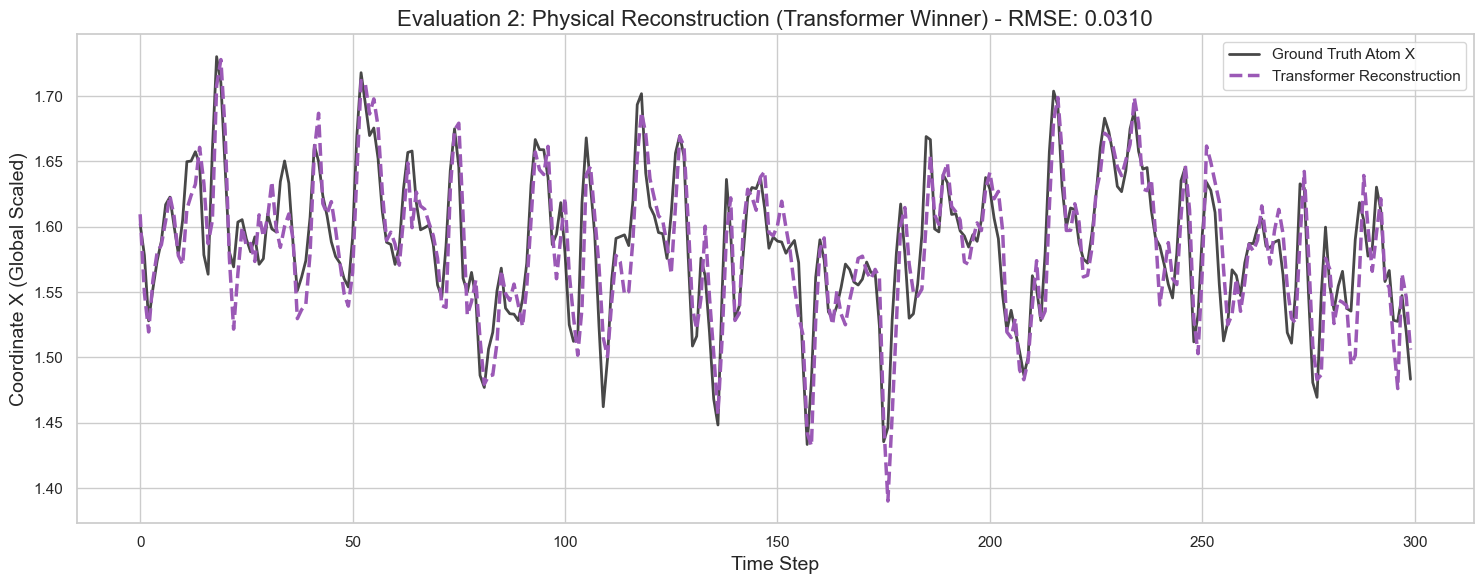

In [4]:
# =============================================================================
# EVALUATION 2: PHYSICAL SPACE RECONSTRUCTION (Transformer Edition)
# =============================================================================
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. DECODER RECONSTRUCTION UTILITY
# Replicates the exact architecture of the Decoder defined in the Autoencoder step.
# This is necessary to use the decoder as a standalone generator.
def build_decoder_standalone(latent_dim, single_dim):
    reg = regularizers.l2(1e-7)
    dec_input = layers.Input(shape=(latent_dim,), name="latent_input")
    
    # --- Head 1: Coordinates (Geometry) ---
    d_c = layers.Dense(256, kernel_regularizer=reg)(dec_input)
    d_c = layers.BatchNormalization()(d_c)
    d_c = layers.Activation("swish")(d_c)
    
    d_c = layers.Dense(512, kernel_regularizer=reg)(d_c)
    d_c = layers.BatchNormalization()(d_c)
    d_c = layers.Activation("swish")(d_c)
    
    out_coords = layers.Dense(single_dim, activation="linear", name="out_coords")(d_c)
    
    # --- Head 2: Velocity (Momentum) ---
    d_v = layers.Dense(256, kernel_regularizer=reg)(dec_input)
    d_v = layers.BatchNormalization()(d_v)
    d_v = layers.Activation("swish")(d_v)
    
    d_v = layers.Dense(512, kernel_regularizer=reg)(d_v)
    d_v = layers.BatchNormalization()(d_v)
    d_v = layers.Activation("swish")(d_v)
    
    d_v = layers.Dense(512, kernel_regularizer=reg)(d_v)
    d_v = layers.BatchNormalization()(d_v)
    d_v = layers.Activation("swish")(d_v)
    
    out_velo = layers.Dense(single_dim, activation="linear", name="out_velo")(d_v)
    
    # --- Head 3: Forces (Dynamics) ---
    d_f = layers.Dense(256, kernel_regularizer=reg)(dec_input)
    d_f = layers.BatchNormalization()(d_f)
    d_f = layers.Activation("swish")(d_f)
    
    d_f = layers.Dense(512, kernel_regularizer=reg)(d_f)
    d_f = layers.BatchNormalization()(d_f)
    d_f = layers.Activation("swish")(d_f)
    
    d_f = layers.Dense(512, kernel_regularizer=reg)(d_f)
    d_f = layers.BatchNormalization()(d_f)
    d_f = layers.Activation("swish")(d_f)
    
    out_forces = layers.Dense(single_dim, activation="linear", name="out_forces")(d_f)
    
    return models.Model(dec_input, [out_coords, out_velo, out_forces])

# 2. WEIGHT TRANSFER
AE_MODEL_PATH = "saved_models_triple/triple_ae.keras"

print(f" Extracting Decoder weights from: {AE_MODEL_PATH}")

try:
    # Load the full pre-trained Autoencoder
    full_ae = load_model(AE_MODEL_PATH)
    
    # Detect dimensions dynamically
    LATENT_DIM = 128
    # output_shape is a list for multi-head models: [(batch, dim), (batch, dim), (batch, dim)]
    SINGLE_DIM = full_ae.output_shape[0][1] 
    
    # Build the standalone decoder graph
    decoder = build_decoder_standalone(LATENT_DIM, SINGLE_DIM)
    
    # Transfer weights: Skips the Encoder layers (indices 0 to 17) and keeps the Decoder layers (18+)
    # Note: The index 18 is specific to the Triple-Head v2.0 architecture defined in Step 3.
    decoder.set_weights(full_ae.get_weights()[18:]) 
    print(" Decoder successfully reconstructed.")
    
    # 3. PHYSICAL SPACE PROJECTION & EVALUATION
    print(" Projecting Latent Dynamics to Atomistic Coordinates...")
    
    # y_pred: The latent predictions from the Transformer (Evaluation 1)
    # y_true: The ground truth latent vectors
    # We take [0] because predict returns a list [coords, velo, forces], we focus on Coords here.
    X_pred_phys = decoder.predict(y_pred, verbose=0)[0] 
    X_true_phys = decoder.predict(y_true, verbose=0)[0]
    
    # Calculate RMSE in the physical (scaled) space
    rmse_phys = np.sqrt(mean_squared_error(X_true_phys, X_pred_phys))
    print(f" PHYSICAL RMSE (Transformer): {rmse_phys:.5f}")
    
    # 4. TRAJECTORY VISUALIZATION
    plt.figure(figsize=(15, 6))
    
    # Plotting the first dimension of the first atom (Index 0)
    plt.plot(X_true_phys[:300, 0], 'k', label='Ground Truth Atom X', alpha=0.8)
    plt.plot(X_pred_phys[:300, 0], '--', color='#9b59b6', label='Transformer Reconstruction', linewidth=2.5)
    
    plt.title(f"Evaluation 2: Physical Reconstruction (Transformer Winner) - RMSE: {rmse_phys:.4f}")
    plt.xlabel("Time Step")
    plt.ylabel("Coordinate X (Global Scaled)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("Evaluation_2_Physical_Space_Transformer.jpg", dpi=300)
    plt.show()
    
except Exception as e:
    print(f" ERROR: {e}")

## 4. Evaluation 3: Generative Stability (Autoregressive Test)

Testiamo la capacità del modello di "immaginare" nuova fisica.
Utilizziamo il modello in modalità **Autoregressiva (Loop)**: l'output al tempo `t` diventa l'input per `t+1`.
Visualizziamo il risultato con un **Phase Portrait (PCA)**: se la traiettoria generata (Rosso) rimane all'interno della nuvola di punti reali (Nero), il modello è stabile.

In [5]:
# =============================================================================
# EVALUATION 3: STABILITY COMPARISON (LSTM vs TRANSFORMER)
# =============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.models import load_model
import tensorflow as tf

# 1. CUSTOM CLASS DEFINITION (Required for Transformer)
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.pos_emb = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        return x + self.pos_emb(positions)
    
    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.pos_emb.input_dim, "d_model": self.d_model})
        return config

# 2. LOAD CHAMPION MODELS (FIXED: Added safe_mode=False)
print(" Loading Champion Models...")
lstm_path = "saved_models_dynamics_lstm/LSTM_Best_Run/best_model.keras"
trans_path = "saved_models_dynamics_transformer/Trans_Complex/best_model.keras"

# safe_mode=False is required because we used a Lambda layer in the model definition
lstm_model = load_model(lstm_path, safe_mode=False)
trans_model = load_model(trans_path, custom_objects={'PositionalEmbedding': PositionalEmbedding}, safe_mode=False)

# 3. TRAJECTORY GENERATION FUNCTION
def generate_trajectory(model, start_window, steps, seq_len=10):
    """
    Performs an autoregressive rollout:
    Prediction at t becomes part of the input for t+1.
    """
    current = start_window.copy()
    generated = []
    
    for _ in range(steps):
        # Predict next step
        pred = model.predict(current.reshape(1, seq_len, -1), verbose=0)[0]
        generated.append(pred)
        
        # Update window (Shift left, append prediction)
        current = np.vstack([current[1:], pred])
        
    return np.array(generated)

# 4. EXECUTE GENERATION
STEPS = 1000
# Assuming X_test and y_true are available from previous cells
start_window = X_test[0].copy()

print(f" Generating LSTM trajectory ({STEPS} steps)...")
gen_lstm = generate_trajectory(lstm_model, start_window, STEPS)

print(f" Generating Transformer trajectory ({STEPS} steps)...")
gen_trans = generate_trajectory(trans_model, start_window, STEPS)

# 5. PCA PROJECTION (Fit on Real Data)
print(" Computing PCA...")
pca = PCA(n_components=2)
pca.fit(y_true)

true_pca = pca.transform(y_true)
lstm_pca = pca.transform(gen_lstm)
trans_pca = pca.transform(gen_trans)

# 6. VISUALIZATION: PHASE PORTRAIT COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Ground Truth
axes[0].scatter(true_pca[:, 0], true_pca[:, 1], c='black', alpha=0.1, s=10)
axes[0].set_title('Real Physics (Ground Truth)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Panel 2: LSTM
axes[1].scatter(true_pca[:, 0], true_pca[:, 1], c='black', alpha=0.05, s=10, label='Real Manifold')
axes[1].plot(lstm_pca[:, 0], lstm_pca[:, 1], c='#2ecc71', linewidth=1.5, alpha=0.8, label='LSTM Trajectory')
axes[1].scatter(lstm_pca[0,0], lstm_pca[0,1], c='green', s=100, marker='o', zorder=5, label='Start')
axes[1].scatter(lstm_pca[-1,0], lstm_pca[-1,1], c='darkgreen', s=100, marker='X', zorder=5, label='End')
axes[1].set_title(f'LSTM Generated ({STEPS} steps)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

# Panel 3: Transformer
axes[2].scatter(true_pca[:, 0], true_pca[:, 1], c='black', alpha=0.05, s=10, label='Real Manifold')
axes[2].plot(trans_pca[:, 0], trans_pca[:, 1], c='#e74c3c', linewidth=1.5, alpha=0.8, label='Transformer Trajectory')
axes[2].scatter(trans_pca[0,0], trans_pca[0,1], c='red', s=100, marker='o', zorder=5, label='Start')
axes[2].scatter(trans_pca[-1,0], trans_pca[-1,1], c='darkred', s=100, marker='X', zorder=5, label='End')
axes[2].set_title(f'Transformer Generated ({STEPS} steps)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend()

plt.suptitle('Stability Comparison: LSTM vs Transformer (1000-step Rollout)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Evaluation_5_LSTM_vs_Transformer_Stability.jpg", dpi=300)
plt.show()

# 7. QUANTITATIVE DIVERGENCE ANALYSIS
checkpoints = [10, 50, 100, 200, 500, 1000]
centroid = y_true.mean(axis=0)
real_variance = np.mean(np.var(y_true, axis=0))

print("\n DIVERGENCE ANALYSIS (Mean Squared Distance from Centroid)")
print("=" * 60)
print(f"{'Step':<10} {'LSTM':<20} {'Transformer':<20}")
print("-" * 60)

lstm_div, trans_div = [], []
for step in checkpoints:
    # Calculate distance of the specific frame at 'step' from the global centroid
    lstm_dist = np.mean((gen_lstm[step-1] - centroid)**2)
    trans_dist = np.mean((gen_trans[step-1] - centroid)**2)
    
    lstm_div.append(lstm_dist)
    trans_div.append(trans_dist)
    print(f"{step:<10} {lstm_dist:<20.4f} {trans_dist:<20.4f}")

print("-" * 60)
print(f"{'Real Var:':<10} {real_variance:.4f} (Reference Threshold)")

# Plot Divergence
plt.figure(figsize=(10, 5))
plt.plot(checkpoints, lstm_div, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='LSTM')
plt.plot(checkpoints, trans_div, 's-', color='#e74c3c', linewidth=2, markersize=8, label='Transformer')
plt.axhline(y=real_variance, color='black', linestyle='--', linewidth=2, label='Natural Physics Variance')
plt.xlabel('Rollout Steps')
plt.ylabel('MSE from Centroid (Divergence)')
plt.title('Divergence Analysis: Long-term Stability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Evaluation_6_Divergence_Comparison.jpg", dpi=300)
plt.show()

 Loading Champion Models...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


 Generating LSTM trajectory (1000 steps)...


KeyboardInterrupt: 

 PER-DIMENSION EVALUATION: LSTM vs TRANSFORMER

 Loading models...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


 Models loaded!
 Generating predictions...

 LSTM BEST - Metrics per Dimension
          MSE       MAE        R2      Bias
Dim                                        
0    0.032321  0.143834  0.949617  0.010772
1    0.037517  0.153190  0.948788 -0.006993
2    0.041167  0.161799  0.938948  0.009608
3    0.032107  0.142034  0.950132 -0.006459
4    0.027673  0.131868  0.960297  0.023010
5    0.043084  0.165959  0.939331  0.019669
6    0.035782  0.150354  0.949493  0.013889
7    0.040316  0.160842  0.934442  0.029022
8    0.032519  0.143357  0.944581 -0.001575
9    0.038220  0.156259  0.950339  0.021190
10   0.034932  0.149589  0.947096  0.014447
11   0.034306  0.147660  0.942235 -0.003744
12   0.036879  0.153873  0.943873 -0.041179
13   0.047691  0.174258  0.927590  0.011884
14   0.034128  0.147202  0.948158 -0.040034
15   0.039904  0.160304  0.936917 -0.011236
16   0.037257  0.154150  0.949091 -0.017428
17   0.047601  0.173255  0.927506  0.070904
18   0.032900  0.144790  0.942194  0.0104

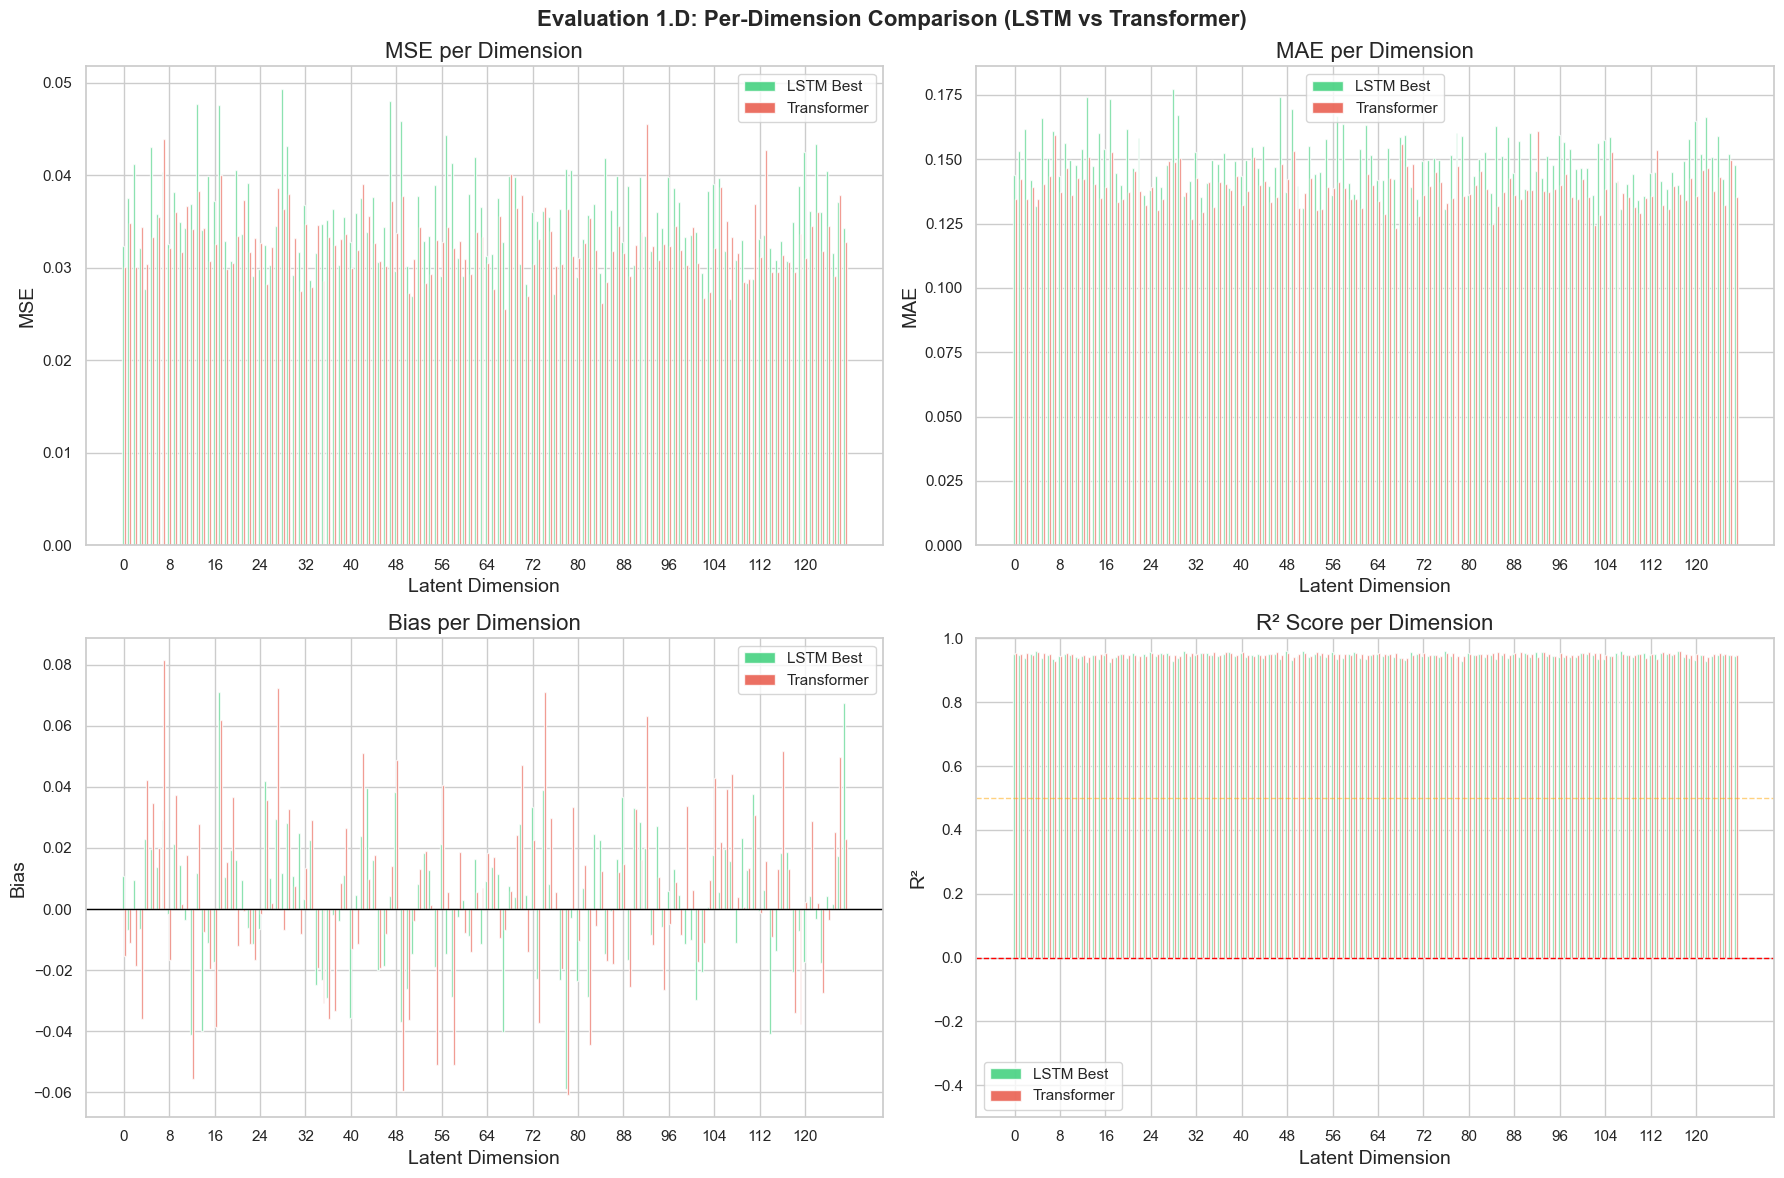


 WINNER PER DIMENSION (based on R²)
   LSTM wins on 37/128 dimensions
   Transformer wins on 91/128 dimensions

 Per-dimension comparison complete!


In [6]:
# =============================================================================
# EVALUATION 1.D: PER-DIMENSION COMPARISON (LSTM vs TRANSFORMER)
# =============================================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import load_model

print("="*70)
print(" PER-DIMENSION EVALUATION: LSTM vs TRANSFORMER")
print("="*70)

# --- 1. LOAD BOTH MODELS ---
LSTM_PATH = "saved_models_dynamics_lstm/LSTM_Best_Run/best_model.keras"
TRANS_PATH = "saved_models_dynamics_transformer/Trans_Complex/best_model.keras"
SEQ_LEN = 10

print("\n Loading models...")
lstm_model = load_model(LSTM_PATH, safe_mode=False)
trans_model = load_model(TRANS_PATH, custom_objects={'PositionalEmbedding': PositionalEmbedding}, safe_mode=False)
print(" Models loaded!")

# --- 2. PREPARE DATA ---
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_test, y_true = create_sequences(test_raw, SEQ_LEN)

# --- 3. GENERATE PREDICTIONS ---
print(" Generating predictions...")
y_pred_lstm = lstm_model.predict(X_test, verbose=0)
y_pred_trans = trans_model.predict(X_test, verbose=0)

n_dims = y_true.shape[1]

# --- 4. COMPUTE METRICS PER DIMENSION ---
def compute_metrics(y_true, y_pred):
    metrics = []
    for i in range(y_true.shape[1]):
        metrics.append({
            'Dim': i,
            'MSE': mean_squared_error(y_true[:, i], y_pred[:, i]),
            'MAE': mean_absolute_error(y_true[:, i], y_pred[:, i]),
            'R2': r2_score(y_true[:, i], y_pred[:, i]),
            'Bias': np.mean(y_pred[:, i] - y_true[:, i])
        })
    return pd.DataFrame(metrics).set_index('Dim')

metrics_lstm = compute_metrics(y_true, y_pred_lstm)
metrics_trans = compute_metrics(y_true, y_pred_trans)

# --- 5. DISPLAY COMPARISON TABLE ---
print("\n" + "="*70)
print(" LSTM BEST - Metrics per Dimension")
print("="*70)
print(metrics_lstm.round(6).to_string())

print("\n" + "="*70)
print(" TRANSFORMER COMPLEX - Metrics per Dimension")
print("="*70)
print(metrics_trans.round(6).to_string())

# --- 6. SUMMARY STATISTICS ---
print("\n" + "="*70)
print(" SUMMARY COMPARISON")
print("="*70)
print(f"{'Metric':<20} {'LSTM Best':<20} {'Transformer':<20}")
print("-"*60)
print(f"{'Mean R²':<20} {metrics_lstm['R2'].mean():.4f} ± {metrics_lstm['R2'].std():.4f}    {metrics_trans['R2'].mean():.4f} ± {metrics_trans['R2'].std():.4f}")
print(f"{'Mean MSE':<20} {metrics_lstm['MSE'].mean():.6f}         {metrics_trans['MSE'].mean():.6f}")
print(f"{'Mean MAE':<20} {metrics_lstm['MAE'].mean():.6f}         {metrics_trans['MAE'].mean():.6f}")
print(f"{'Mean Bias':<20} {metrics_lstm['Bias'].mean():.6f}         {metrics_trans['Bias'].mean():.6f}")
print(f"{'Dims R² > 0.5':<20} {(metrics_lstm['R2'] > 0.5).sum()}/{n_dims}                {(metrics_trans['R2'] > 0.5).sum()}/{n_dims}")
print(f"{'Dims R² < 0':<20} {(metrics_lstm['R2'] < 0).sum()}/{n_dims}                 {(metrics_trans['R2'] < 0).sum()}/{n_dims}")

# --- 7. VISUALIZATION: SIDE-BY-SIDE COMPARISON ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
x = np.arange(n_dims)
width = 0.35

# Panel 1: MSE Comparison
ax1 = axes[0, 0]
ax1.bar(x - width/2, metrics_lstm['MSE'], width, label='LSTM Best', color='#2ecc71', alpha=0.8)
ax1.bar(x + width/2, metrics_trans['MSE'], width, label='Transformer', color='#e74c3c', alpha=0.8)
ax1.set_title('MSE per Dimension')
ax1.set_xlabel('Latent Dimension')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.set_xticks(x[::8])

# Panel 2: MAE Comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, metrics_lstm['MAE'], width, label='LSTM Best', color='#2ecc71', alpha=0.8)
ax2.bar(x + width/2, metrics_trans['MAE'], width, label='Transformer', color='#e74c3c', alpha=0.8)
ax2.set_title('MAE per Dimension')
ax2.set_xlabel('Latent Dimension')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.set_xticks(x[::8])

# Panel 3: Bias Comparison
ax3 = axes[1, 0]
ax3.bar(x - width/2, metrics_lstm['Bias'], width, label='LSTM Best', color='#2ecc71', alpha=0.8)
ax3.bar(x + width/2, metrics_trans['Bias'], width, label='Transformer', color='#e74c3c', alpha=0.8)
ax3.axhline(0, color='black', linestyle='-', linewidth=1)
ax3.set_title('Bias per Dimension')
ax3.set_xlabel('Latent Dimension')
ax3.set_ylabel('Bias')
ax3.legend()
ax3.set_xticks(x[::8])

# Panel 4: R² Comparison
ax4 = axes[1, 1]
ax4.bar(x - width/2, metrics_lstm['R2'], width, label='LSTM Best', color='#2ecc71', alpha=0.8)
ax4.bar(x + width/2, metrics_trans['R2'], width, label='Transformer', color='#e74c3c', alpha=0.8)
ax4.axhline(0, color='red', linestyle='--', linewidth=1)
ax4.axhline(0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_title('R² Score per Dimension')
ax4.set_xlabel('Latent Dimension')
ax4.set_ylabel('R²')
ax4.set_ylim(bottom=min(-0.5, min(metrics_lstm['R2'].min(), metrics_trans['R2'].min())-0.1), top=1.0)
ax4.legend()
ax4.set_xticks(x[::8])

plt.suptitle('Evaluation 1.D: Per-Dimension Comparison (LSTM vs Transformer)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Evaluation_1D_PerDimension_Comparison.jpg", dpi=300)
plt.show()

# --- 8. WINNER PER DIMENSION ---
print("\n" + "="*70)
print(" WINNER PER DIMENSION (based on R²)")
print("="*70)
lstm_wins = (metrics_lstm['R2'] > metrics_trans['R2']).sum()
trans_wins = (metrics_trans['R2'] > metrics_lstm['R2']).sum()
print(f"   LSTM wins on {lstm_wins}/{n_dims} dimensions")
print(f"   Transformer wins on {trans_wins}/{n_dims} dimensions")

print("\n Per-dimension comparison complete!")